In [6]:
# ==========================================
# 1. IMPORT NECESSARY LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow/Keras for the Artificial Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


Loading dataset...


C:\Users\Harshita\AppData\Local\Temp\ipykernel_28560\1066803436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette='viridis')


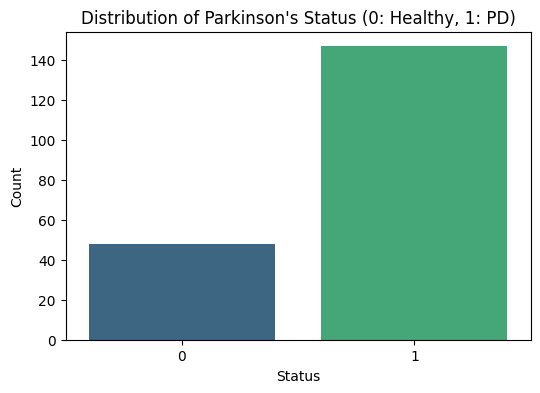

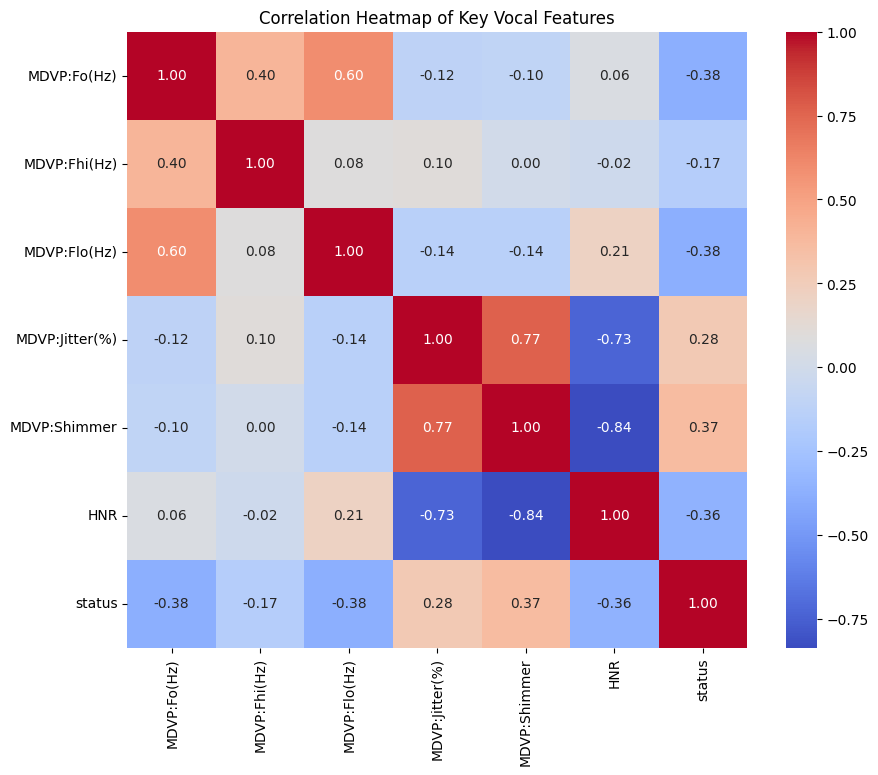

In [9]:
# ==========================================
# 2. LOAD AND EXPLORE THE DATA
# ==========================================
print("Loading dataset...")
df = pd.read_csv("data/parkinsons.csv")

# Visualization 1: Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='status', data=df, palette='viridis')
plt.title('Distribution of Parkinson\'s Status (0: Healthy, 1: PD)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

# Visualization 2: Correlation Heatmap of top features
plt.figure(figsize=(10, 8))
# Selecting a subset of features for a cleaner heatmap
cols_to_plot = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR', 'status']
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Vocal Features')
plt.show()


In [10]:
# ==========================================
# 3. DATA PREPROCESSING
# ==========================================
# Drop the 'name' column as it's just an ID and holds no predictive value
X = df.drop(['name', 'status'], axis=1)
y = df['status']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling: Neural Networks are highly sensitive to unscaled data.
# We fit the scaler ONLY on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
# ==========================================
# 4. BUILD THE ARTIFICIAL NEURAL NETWORK
# ==========================================
print("\nBuilding the ANN Model...")
model = Sequential()

# Input Layer & 1st Hidden Layer
# 32 Neurons, ReLU activation function
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
# Dropout layer: Randomly drops 30% of neurons to prevent overfitting
model.add(Dropout(0.3))

# 2nd Hidden Layer
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
# 1 Neuron, Sigmoid activation (outputs a probability between 0 and 1 for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the Model
# Adam optimizer is highly efficient. Binary Crossentropy is the standard loss function for Yes/No tasks.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the architecture
model.summary()




Building the ANN Model...


c:\Users\Harshita\Desktop\ML-DL lab\venv-dl\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ==========================================
# 5. TRAIN THE MODEL
# ==========================================
# Early stopping will monitor validation loss and stop training if it doesn't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\nTraining the Model...")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=150,           # Maximum number of passes
    batch_size=16,        # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data to evaluate during training
    callbacks=[early_stop], 
    verbose=1             # Set to 0 if you don't want the epoch loading bars to print
)



Training the Model...
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4032 - loss: 0.7957 - val_accuracy: 0.5938 - val_loss: 0.6346
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6210 - loss: 0.6292 - val_accuracy: 0.7812 - val_loss: 0.5696
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5081 - loss: 0.6726 - val_accuracy: 0.8125 - val_loss: 0.5171
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6613 - loss: 0.5882 - val_accuracy: 0.8125 - val_loss: 0.4760
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7177 - loss: 0.5403 - val_accuracy: 0.8438 - val_loss: 0.4433
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5407 - val_accuracy: 0.8750 - val_loss: 0.4141
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7419 - loss: 0.4919 - val_accuracy: 0.9375 - val_loss: 0.3911
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8065 - loss: 0.4706 - val_accuracy:

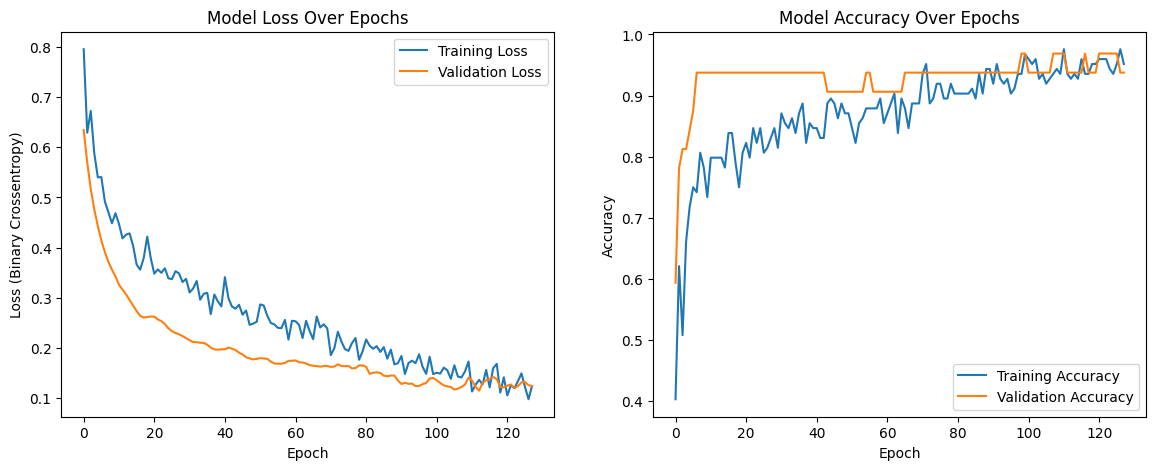

In [13]:

# ==========================================
# 6. VISUALIZE TRAINING PERFORMANCE
# ==========================================
# Create a figure with two subplots: Loss and Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training vs Validation Loss
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.legend()

# Plot Training vs Validation Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Model Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()



Evaluating Model on Unseen Test Data...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Test Accuracy: 94.87%

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.94      1.00      0.97        29

    accuracy                           0.95        39
   macro avg       0.97      0.90      0.93        39
weighted avg       0.95      0.95      0.95        39



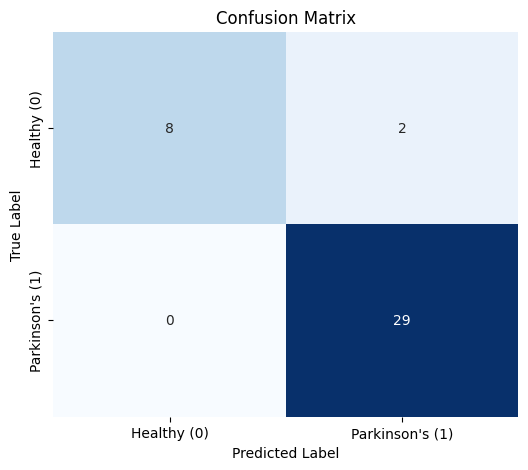

In [14]:

# ==========================================
# 7. EVALUATE ON TEST DATA
# ==========================================
print("\nEvaluating Model on Unseen Test Data...")
# Predict probabilities for the test set
y_pred_probs = model.predict(X_test_scaled)
# Convert probabilities to binary class labels (0 or 1) using a 0.5 threshold
y_pred = (y_pred_probs > 0.5).astype(int)

# Print metrics
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualization 3: Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy (0)', 'Parkinson\'s (1)'],
            yticklabels=['Healthy (0)', 'Parkinson\'s (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
# ==========================================
# 8. HYPERPARAMETER TUNING WITH KERAS TUNER
# ==========================================
import keras_tuner as kt

# 1. Define a "Model Builder" function
def model_builder(hp):
    model = tf.keras.Sequential()
    
    # Tune the number of units in the first Dense layer
    # Choose an optimal value between 16-64
    hp_units = hp.Int('units', min_value=16, max_value=64, step=16)
    model.add(tf.keras.layers.Dense(units=hp_units, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    
    # Tune the dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    model.add(tf.keras.layers.Dropout(rate=hp_dropout))
    
    model.add(tf.keras.layers.Dense(16, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    return model

# 2. Initialize the Tuner (RandomSearch)
tuner = kt.RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=5,      # It will try 5 different combinations
    directory='my_dir',
    project_name='intro_to_kt'
)

# 3. Run the Search
print("\n--- Starting Automated Hyperparameter Tuning ---")
tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.2)

# 4. Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. 
- The optimal number of units in the first layer is: {best_hps.get('units')}
- The optimal dropout rate is: {best_hps.get('dropout')}
- The optimal learning rate is: {best_hps.get('learning_rate')}
""")

Trial 5 Complete [00h 00m 05s]
val_accuracy: 0.96875

Best val_accuracy So Far: 0.96875
Total elapsed time: 00h 00m 34s

The hyperparameter search is complete. 
- The optimal number of units in the first layer is: 16
- The optimal dropout rate is: 0.30000000000000004
- The optimal learning rate is: 0.01

